In [1]:

import os
import re
import pandas as pd
import numpy as np
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from tqdm import tqdm
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings("ignore")



In [2]:
splits = {
    'train': 'task_a/task_a_training_set_1.parquet', 
    'validation': 'task_a/task_a_validation_set.parquet', 
    'test': 'task_a/task_a_test_set_sample.parquet'
}

base_path = "hf://datasets/DaniilOr/SemEval-2026-Task13/"

# Load each split into Pandas
train_data = pd.read_parquet(base_path + splits["train"])
val_data = pd.read_parquet(base_path + splits["validation"])
test_data = pd.read_parquet(base_path + splits["test"])

In [3]:
train_data.head(2)

,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python


In [4]:
X_train_text, y_train = train_data["code"], train_data["label"]
X_test_text, y_test = test_data["code"], test_data["label"]
X_val_text, y_val = val_data["code"], val_data["label"]

In [ ]:
# after hypertuning of the model
best_params = {
    'max_features': 30000, 
    'ngram_range': (1, 1), 
    'min_df': 0.0015430189491796615, 
    'C': 8.853443301355558, 
    'solver': 'liblinear', 
    'class_weight': 'balanced'
    }

In [6]:
tfidf = TfidfVectorizer(
        strip_accents="unicode",
        analyzer="word",
        max_features=best_params["max_features"],
        ngram_range=best_params["ngram_range"],
        min_df=best_params["min_df"]
    )


X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
# validation data
X_val_tfidf  = tfidf.transform(X_val_text)

### LogisticRegression Model

In [8]:
logisticRegressionclf =  LogisticRegression(
            C=best_params['C'],
            solver=best_params['solver'],
            class_weight=best_params['class_weight'],
            max_iter=5000,
            n_jobs=-1
        )

print("="*60)    
logisticRegressionclf.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,8.853443301355558
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [9]:

def custom_predict(model, X_data, threshold):
    """
    Generates class predictions based on a custom threshold.
    """
    probs = model.predict_proba(X_data)
    # Return 1 if the positive class probability is >= threshold, else 0
    return (probs[:, 1] >= threshold).astype(int)


In [12]:
# Usage:
pred = custom_predict(logisticRegressionclf, X_test_tfidf, threshold=0.6)


acc = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(classification_report(y_test, pred))
print("="*60)
print(f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

              precision    recall  f1-score   support

           0       0.90      0.41      0.57       777
           1       0.29      0.83      0.43       223

    accuracy                           0.51      1000
   macro avg       0.59      0.62      0.50      1000
weighted avg       0.76      0.51      0.54      1000

Accuracy: 0.5080, F1 Score: 0.4306


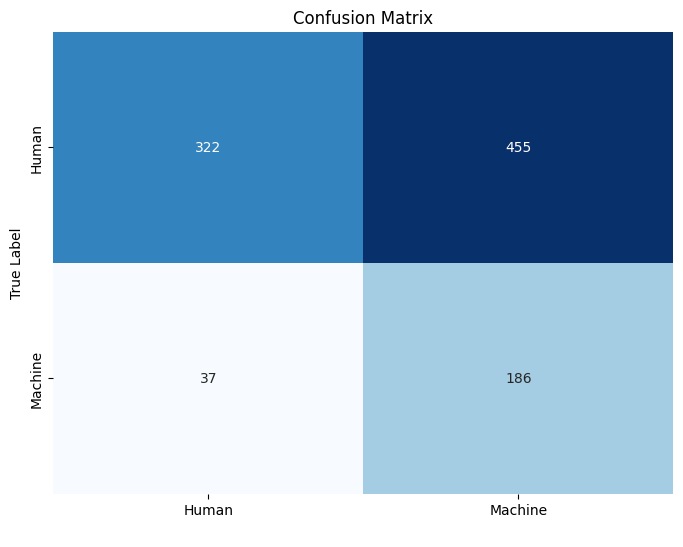

In [14]:
#  i want to show it using giraphical representation  give name to lable  "human": 0, "machine": 1
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Human', 'Machine'],
            yticklabels=['Human', 'Machine'])   
plt.xlabel(' ')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
# Save figure as PDF
plt.savefig("plots/confusion_matrix_logistic_regression_human_vs_machine.pdf", bbox_inches="tight")
plt.show()


In [18]:

report = classification_report(y_test, pred, output_dict=True,target_names=['Human', 'Machine'])
pd.DataFrame(report)

,Human,Machine,accuracy,macro avg,weighted avg
precision,0.896936,0.290172,0.508,0.593554,0.761627
recall,0.414414,0.834081,0.508,0.624248,0.508000
f1-score,0.566901,0.430556,0.508,0.498728,0.536496
support,777.000000,223.000000,0.508,1000.000000,1000.000000


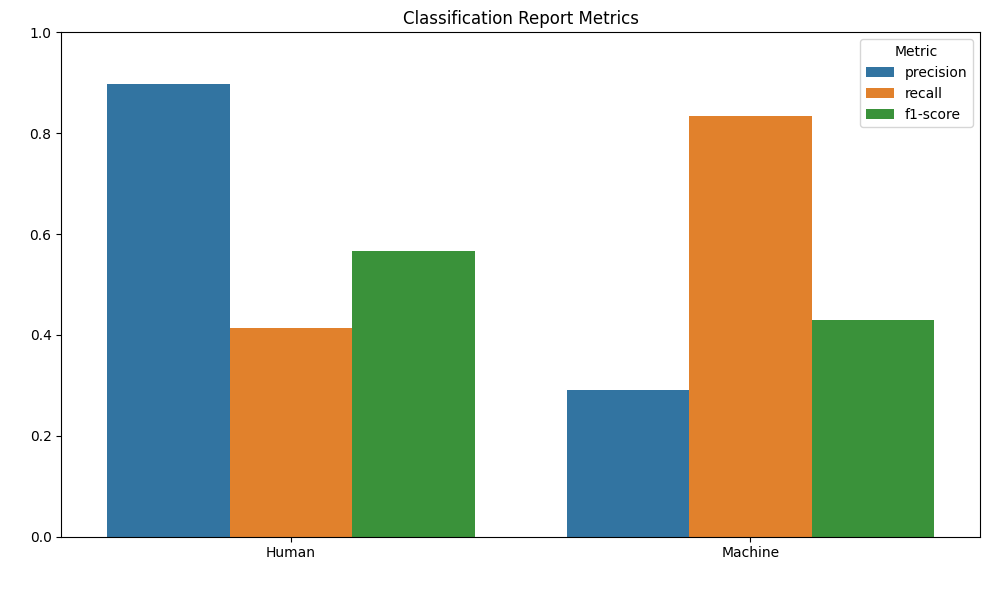

In [15]:
# Generate classification report
report = classification_report(y_test, pred, output_dict=True)
df = pd.DataFrame(report).transpose()

# Keep only class rows (drop accuracy, macro avg, weighted avg)
metrics = df.iloc[:-3][['precision', 'recall', 'f1-score']]

# Rename classes
metrics.index = metrics.index.map({
    '0': 'Human',
    '1': 'Machine'
})

# Convert to long format for seaborn
metrics_long = metrics.reset_index().melt(
    id_vars='index',
    var_name='Metric',
    value_name='Score'
)

# Plot with seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=metrics_long,
    x='index',
    y='Score',
    hue='Metric'
)

plt.title("Classification Report Metrics")
plt.xlabel(" ")
plt.ylabel(" ")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("plots/classification_report_metrics.pdf", bbox_inches="tight")
plt.show()